In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
# Load dataset
print("Saravanan 24BAD105")
df = pd.read_csv(r"C:\Users\User\Downloads\ML\EXP-5\archive (8)\breast-cancer.csv")

print(df.head())
print(df.info())
print(df.describe())

Saravanan 24BAD105
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perime

In [3]:
# Select required features
features = ['radius_mean', 'texture_mean', 
            'perimeter_mean', 'area_mean', 
            'smoothness_mean']

X = df[features]
y = df['diagnosis']

In [4]:
le = LabelEncoder()
y = le.fit_transform(y)   # M=1, B=0

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

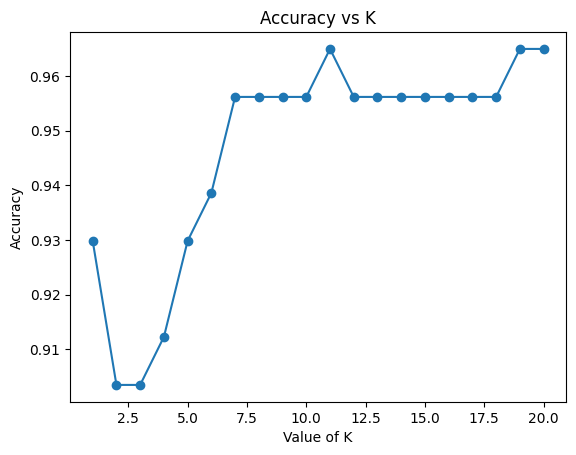

In [7]:
accuracy_list = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

# Plot Accuracy vs K
plt.plot(range(1,21), accuracy_list, marker='o')
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

In [8]:
best_k = accuracy_list.index(max(accuracy_list)) + 1
print("Best K:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

Best K: 11


Accuracy: 0.9649122807017544

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



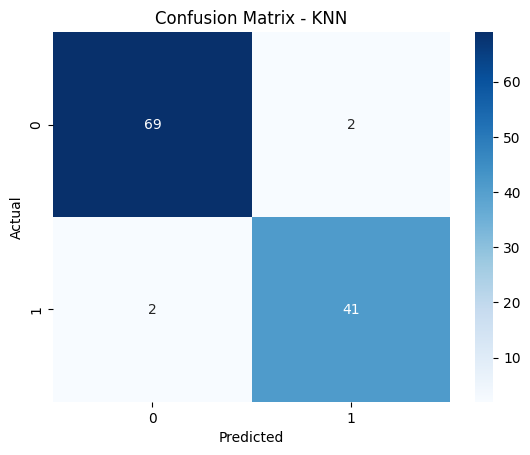

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()

Number of Misclassified Samples: 4


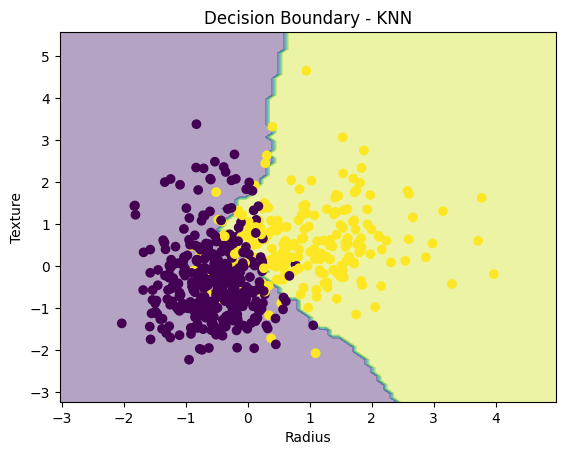

In [10]:
misclassified = np.where(y_test != y_pred)
print("Number of Misclassified Samples:", len(misclassified[0]))

# Use only 2 features for visualization
X_vis = df[['radius_mean','texture_mean']]
X_vis_scaled = scaler.fit_transform(X_vis)
y_vis = le.fit_transform(df['diagnosis'])

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis_scaled, y_vis, test_size=0.2, random_state=42)

model_v = KNeighborsClassifier(n_neighbors=best_k)
model_v.fit(X_train_v, y_train_v)

# Create meshgrid
x_min, x_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
y_min, y_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model_v.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_vis_scaled[:,0], X_vis_scaled[:,1], c=y_vis)
plt.xlabel("Radius")
plt.ylabel("Texture")
plt.title("Decision Boundary - KNN")
plt.show()